# Gas opacity tables: R10K and R30K

Plot the Brewster pickle cross sections at a specified pressure and temperature.
These are cross sections per absorbing particle, not abundance-weighted opacity,
optical depth, or an emergent spectrum. The plots use native sampling without
instrumental convolution or display rebinning.

Install `numpy`, `scipy`, `matplotlib`, and `jupyter` in your plotting environment.
Open this notebook in `docs/source/tutorials/`. The default project path below
assumes the kernel starts in that directory; edit it if your working directory
is different. Set `opacity_directory` to your downloaded Linelists folder.
Only load pickle files from a source you trust.


In [1]:
from pathlib import Path
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

project_root = Path("../../..").resolve()
opacity_directory = project_root.parent / "Linelists"
output_directory = Path(".")

if not (project_root / "data/gaslistR10K.dat").is_file():
    raise FileNotFoundError("Set project_root to the Brewster repository root")
if not opacity_directory.is_dir():
    raise FileNotFoundError("Set opacity_directory to your downloaded Linelists folder")


## Read the cross section at the requested P and T

The `.pic` tuple contains wavenumber (cm⁻¹), pressure (bar), temperature (K),
and linear cross section (cm² per absorbing particle), with array axes
`(pressure, temperature, wavenumber)`. The reader interpolates log cross section
linearly in log pressure and log temperature. It rejects out-of-range requests
and invalid values rather than extrapolating or substituting opacity floors.

This corrects the reference notebook's pressure indexing: after interpolation
onto a new pressure grid, an index from the original grid cannot be reused.


In [2]:
def opacity_at_pt(opacity_file, temperature, pressure, wavelength_range):
    """Read a Brewster .pic cross-section table at P (bar) and T (K)."""
    with Path(opacity_file).open("rb") as handle:
        wavenumber, table_pressure, table_temperature, cross_section = pickle.load(handle)

    wavenumber = np.asarray(wavenumber, dtype=float)
    table_pressure = np.asarray(table_pressure, dtype=float)
    table_temperature = np.asarray(table_temperature, dtype=float)
    if cross_section.shape != (table_pressure.size, table_temperature.size, wavenumber.size):
        raise ValueError(f"Unexpected opacity shape in {opacity_file}")
    for name, grid in (("wavenumber", wavenumber), ("pressure", table_pressure),
                       ("temperature", table_temperature)):
        if not np.all(np.isfinite(grid)) or np.any(grid <= 0) or np.any(np.diff(grid) <= 0):
            raise ValueError(f"Expected a finite, positive, increasing {name} grid")
    if not table_pressure[0] <= pressure <= table_pressure[-1]:
        raise ValueError("Requested pressure is outside the table")
    if not table_temperature[0] <= temperature <= table_temperature[-1]:
        raise ValueError("Requested temperature is outside the table")
    w1, w2 = wavelength_range
    if not 0 < w1 < w2:
        raise ValueError("Wavelength limits must be positive and increasing")
    if w1 < 1e4 / wavenumber[-1] or w2 > 1e4 / wavenumber[0]:
        raise ValueError("Requested wavelength range is outside the table")
    selected = (wavenumber >= 1e4 / w2) & (wavenumber <= 1e4 / w1)
    if np.count_nonzero(selected) < 2:
        raise ValueError("Wavelength range contains fewer than two samples")
    # Read only the P/T brackets that contribute to this request. Other
    # temperatures in a supplied table can contain invalid, unused values.
    indices = []
    for grid, target in ((table_pressure, pressure), (table_temperature, temperature)):
        upper = np.searchsorted(grid, target)
        if grid[upper] == target:
            indices.append(np.array([upper]))
        else:
            indices.append(np.array([upper - 1, upper]))
    p_indices, t_indices = indices
    sigma = np.asarray(cross_section[np.ix_(p_indices, t_indices, np.flatnonzero(selected))],
                       dtype=float)
    if not np.all(np.isfinite(sigma)) or np.any(sigma <= 0):
        raise ValueError("Selected cross sections contain non-finite or non-positive values")

    # Interpolate log cross section in log P and log T, as in the line-opacity
    # path, without using indices from a different pressure grid.
    if p_indices.size == 1:
        log_sigma_at_p = np.log10(sigma[0])
    else:
        log_sigma_at_p = interp1d(
            np.log10(table_pressure[p_indices]), np.log10(sigma), axis=0,
            bounds_error=True,
        )(np.log10(pressure))
    if t_indices.size == 1:
        log_sigma_at_pt = log_sigma_at_p[0]
    else:
        log_sigma_at_pt = interp1d(
            np.log10(table_temperature[t_indices]), log_sigma_at_p, axis=0,
            bounds_error=True,
        )(np.log10(temperature))
    wavelength = 1e4 / wavenumber[selected]
    return wavelength[::-1], (10**log_sigma_at_pt)[::-1]


def gas_files(xlist, opacity_directory):
    """Use the manifest's filenames rather than guessing them from gas names."""
    rows = np.loadtxt(xlist, dtype=str, ndmin=2)
    return {row[1].lower(): Path(opacity_directory) / row[3] for row in rows}


h2o: h2o_ucl2017_xsecs_R10K.pic, 18972 wavelength samples
co: co_xsecs_R10K.pic, 18972 wavelength samples
co2: co2_xsecs_R10K.pic, 18972 wavelength samples
ch4: 12C1H4_xsecs_R10K.pic, 18972 wavelength samples
nh3: nh3_xsecs_R10K.pic, 18972 wavelength samples
feh: feh_xsecs_R10K.pic, 18972 wavelength samples
na: Na_xsecs_R10K.pic, 18972 wavelength samples
k: K_xsecs_R10K.pic, 18972 wavelength samples


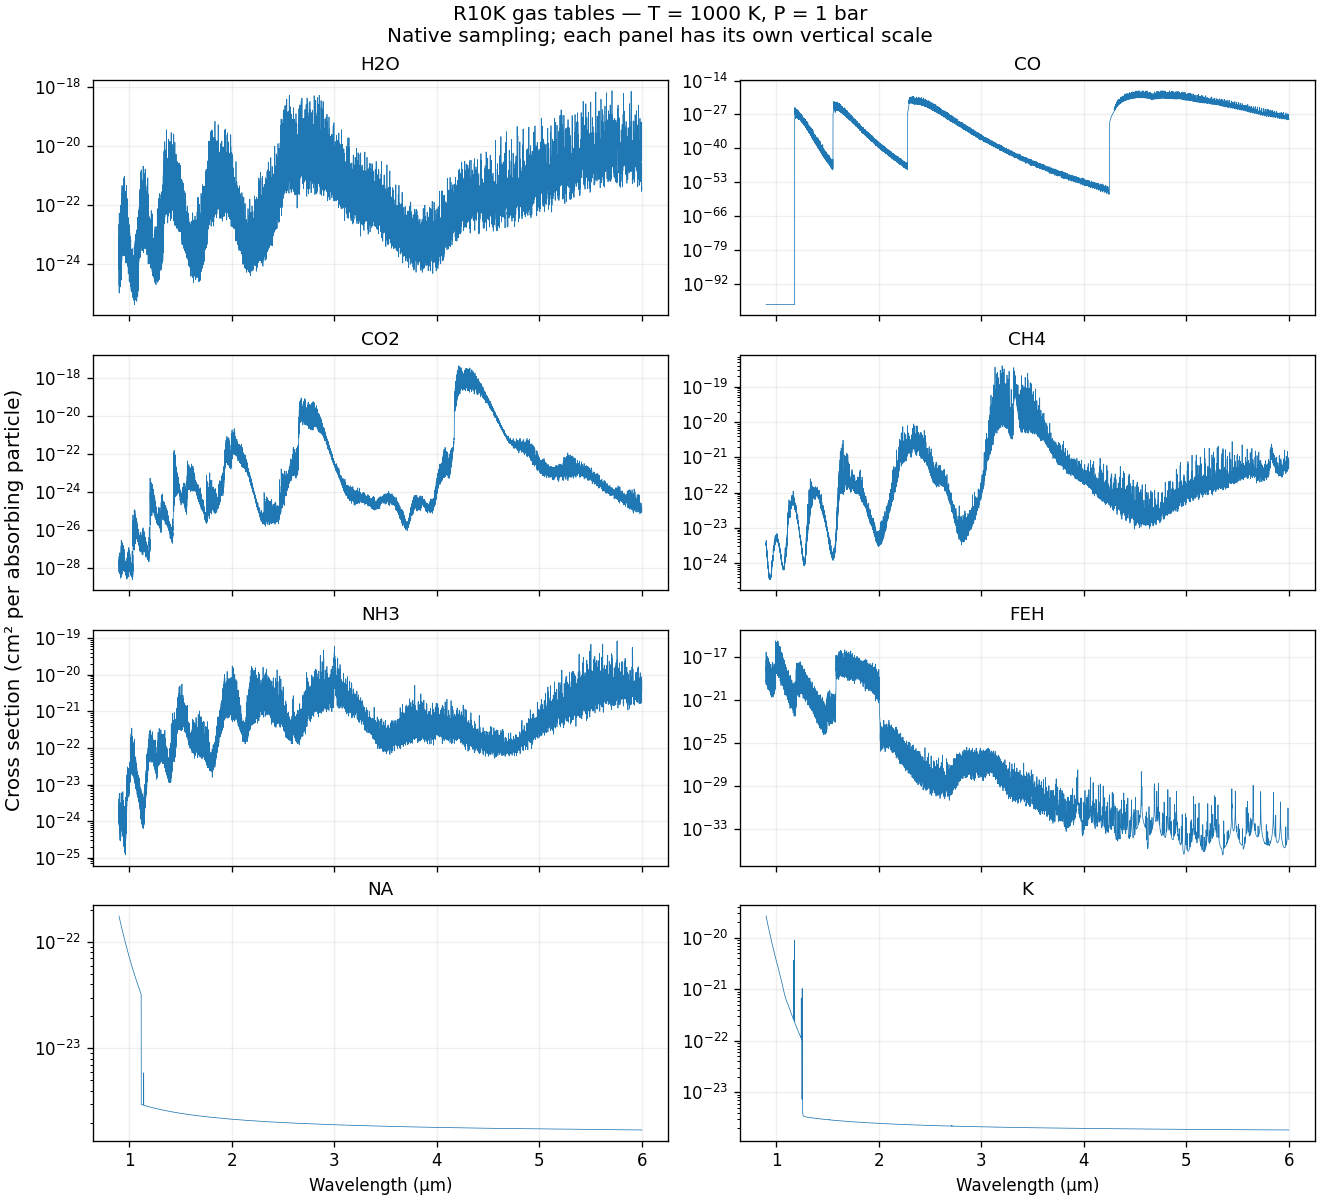

In [3]:
temperature = 1000.0  # K; illustrative, not a retrieved atmosphere
pressure = 1.0        # bar
wavelength_range = (0.9, 6.0)  # micrometres
species = ["h2o", "co", "co2", "ch4", "nh3", "feh", "na", "k"]
files_10k = gas_files(project_root / "data/gaslistR10K.dat", opacity_directory)

fig, axes = plt.subplots(4, 2, figsize=(11, 10), sharex=True, constrained_layout=True)
for ax, gas in zip(axes.flat, species):
    wavelength, sigma = opacity_at_pt(
        files_10k[gas], temperature, pressure, wavelength_range,
    )
    ax.plot(wavelength, sigma, linewidth=0.45)
    ax.set_yscale("log")
    ax.set_title(gas.upper(), fontsize=11)
    ax.grid(alpha=0.2)
    print(f"{gas}: {files_10k[gas].name}, {wavelength.size} wavelength samples")
for ax in axes[-1]:
    ax.set_xlabel("Wavelength (µm)")
fig.supylabel("Cross section (cm² per absorbing particle)")
fig.suptitle(f"R10K gas tables — T = {temperature:g} K, P = {pressure:g} bar\n"
             "Native sampling; each panel has its own vertical scale")
fig.savefig(output_directory / "gas_opacity_r10k.png", dpi=180)
plt.show()


## Compare the native sampling of R10K and R30K

Use the same gas, pressure, temperature, and wavelength interval in both files.
The R30K table has finer wavelength sampling. This comparison does not establish
that the underlying line data or broadening prescriptions are identical; the
filenames alone cannot prove that. In particular, the current R10K and R30K
manifests select different methane filenames.

No interpolation onto a common wavelength grid is needed to overlay these
curves. The plotted cross sections have not been convolved with an instrument.


R10K: co_xsecs_R10K.pic; median sampling R = 10000.5
R30K: co_xsecs_R30K.pic; median sampling R = 30000.5


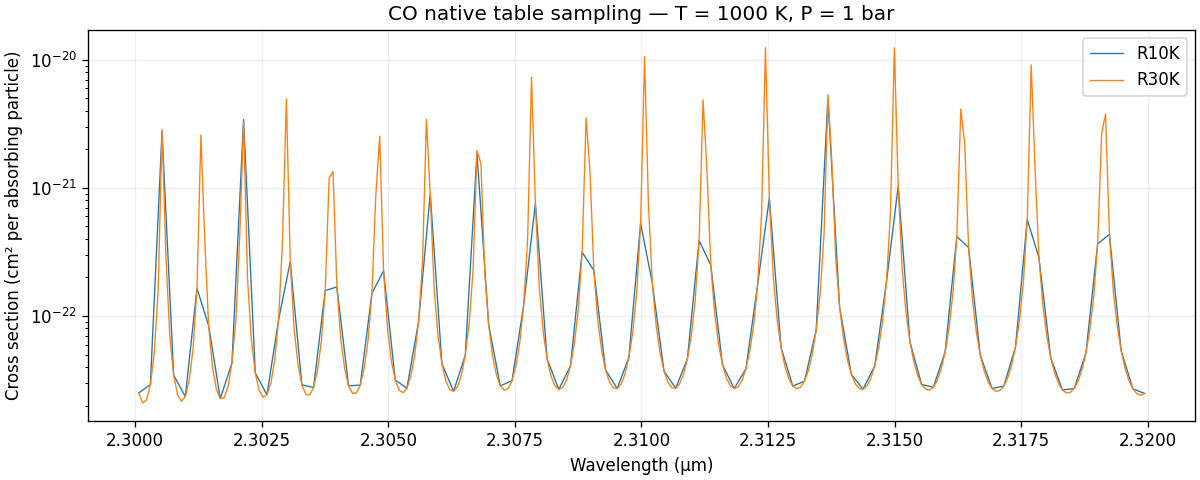

In [4]:
files_30k = gas_files(project_root / "data/gaslistR30K.dat", opacity_directory)
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
for label, files in (("R10K", files_10k), ("R30K", files_30k)):
    wavelength, sigma = opacity_at_pt(
        files["co"], temperature, pressure, (2.30, 2.32),
    )
    sampling_r = np.median(
        0.5 * (wavelength[1:] + wavelength[:-1]) / np.diff(wavelength)
    )
    ax.plot(wavelength, sigma, linewidth=0.8, label=label)
    print(f"{label}: {files['co'].name}; median sampling R = {sampling_r:.1f}")
ax.set_yscale("log")
ax.set_xlabel("Wavelength (µm)")
ax.set_ylabel("Cross section (cm² per absorbing particle)")
ax.set_title(f"CO native table sampling — T = {temperature:g} K, P = {pressure:g} bar")
ax.legend()
ax.grid(alpha=0.2)
fig.savefig(output_directory / "gas_opacity_resolution.png", dpi=180)
plt.show()
